In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyreadstat import read_sav
from pyreadstat import metadata_container

np.random.seed(42)

In [4]:
df: pd.DataFrame; meta: metadata_container
df, meta = read_sav('data.sav')
df = df.drop('k4_new', axis=1)
print(df.shape)
df.head()

(2695, 22)


,Cреднеспис.числ.работн,k1,k2,k3,k4,k5,k6,k7,k8,k9,k10,k11,k12,k13,k14,k15,k16,k17,k18,k19,k20,Year
0,6095.0,0.942380,0.060563,0.678302,-0.161531,0.202055,0.165019,0.399033,0.799019,5.426569,0.209235,1.115922,1.082798,0.655937,4.454819,3.975687,0.892446,1007.536232,0.076738,0.055049,0.034904,5.0
1,255.0,1.980494,0.274382,0.916775,0.624425,0.089377,0.220648,0.000000,0.933519,14.041958,0.215083,1.259382,1.123828,0.705951,10.618881,12.295547,1.157895,357.294118,0.116068,0.059740,0.025647,5.0
2,114.0,0.374160,0.001494,0.085138,-1.504990,0.235739,0.508929,0.888889,0.779049,5.017007,0.096737,0.774586,1.185374,0.123415,0.794785,6.258929,7.875000,36.894737,-0.584879,0.010563,0.000000,5.0
3,365.0,7.859079,0.831978,2.449864,0.875862,0.059439,0.030030,0.011111,0.942010,16.244444,0.876663,1.223284,1.309449,2.804607,48.363889,26.142643,0.540541,33.676983,0.171731,0.496295,0.312415,5.0
4,168.0,1.779376,0.005596,0.883293,0.527853,0.135491,0.886686,0.489796,0.887341,10.558673,0.313389,0.874381,0.994832,0.473041,5.628827,3.125354,0.555241,19.103896,0.064809,0.025726,0.011839,5.0


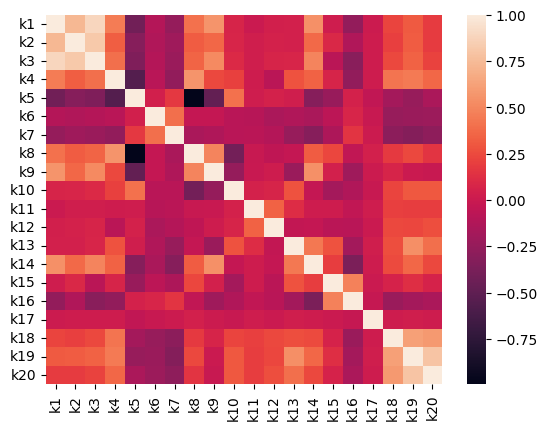

-0.996377824208808


In [5]:
sns.heatmap(df[df.columns[1:-1]].corr())
plt.show()
print(df[df.columns[1:-1]].corr()['k5']['k8'])

df = df.drop('k8', axis=1)
NUM_COLS = df.columns[1:-1]

Нахождение выбросов (Isolation forest)

In [6]:
from sklearn.ensemble import IsolationForest

df_train: pd.DataFrame; df_test: pd.DataFrame
print(f"Shape: {df.shape}")

clf = IsolationForest(
    n_estimators=500,           # Больше деревьев = стабильнее
    max_samples='auto',         # Можно попробовать 256, 512, 1024
    contamination='auto',       # или 0.05, или подобрать вручную
    max_features=0.8,           # Используем не все признаки сразу (боремся с шумом)
    bootstrap=False,
    random_state=42
)

clf.fit(df[NUM_COLS])
outliers_train: np.ndarray = clf.predict(df[NUM_COLS])

print(f"Number of outliers in df: {np.abs( outliers_train[outliers_train == -1].sum() )}")

Shape: (2695, 21)
Number of outliers in df: 136


Винсоризация:

In [7]:
outliers_mask = (outliers_train == -1)

percentiles = {}
for col in NUM_COLS:
    p_low: float = df[col][outliers_mask != 1].min()
    p_high = df[col][outliers_mask != 1].max()
    percentiles[col] = (p_low, p_high)

df_clean: pd.DataFrame = df.copy()
for col in NUM_COLS:
    low, high = percentiles[col]
    col_data = df_clean[col][outliers_mask]
    col_data[col_data < low] = low
    col_data[col_data > high] = high
    df_clean.loc[outliers_mask, col] = col_data

    
#df_clean = df[outliers_mask != 1]


Стандартизация:

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(df_clean)

df_array: np.ndarray = scaler.transform(df_clean)
df_stand: pd.DataFrame = pd.DataFrame(df_array,
                                             columns=df_clean.columns,
                                               index=df_clean.index)


Метод главных компонент:

In [9]:
from sklearn.decomposition import PCA

n_pca_components: int = 6
total_variance = np.sum(np.var(df_stand[NUM_COLS], axis=0, ddof=1))

pca = PCA(n_components=n_pca_components, random_state=42)
pca.fit(df_stand[NUM_COLS])
pca_eigen_values: np.ndarray = pca.explained_variance_

pca_res_df = pd.DataFrame(
    {"Eigen values": pca_eigen_values,
        "Explained variance ratio": pca.explained_variance_ratio_,
            "Cumsum of explained variance ratio": np.cumsum(pca.explained_variance_ratio_)},
    index=[i for i in range(n_pca_components)]
)
print(pca_res_df)

pca_array: np.ndarray = pca.transform(df_stand[NUM_COLS])
pca_columns: list[str] = ['pca_' + str(i + 1) for i in range(n_pca_components)]
df_pca: pd.DataFrame = pd.DataFrame(pca_array, columns=pca_columns, index=df_stand.index)
print("\nDataframe in principal components space:")
print(f"Shape: {df_pca.shape}")
print(df_pca.head())

   Eigen values  Explained variance ratio  Cumsum of explained variance ratio
0      5.131626                  0.269985                            0.269985
1      2.746323                  0.144490                            0.414475
2      1.724670                  0.090738                            0.505213
3      1.412437                  0.074311                            0.579525
4      1.156782                  0.060861                            0.640385
5      1.132669                  0.059592                            0.699977

Dataframe in principal components space:
Shape: (2695, 6)
      pca_1     pca_2     pca_3     pca_4     pca_5     pca_6
0 -1.062975  0.606016 -0.354002  0.288986 -0.852363  0.689220
1  0.892079  1.388750  0.435714  0.423050 -1.109801  0.258063
2 -5.405600  2.756024  0.156487 -0.176024  1.581223  1.062442
3  7.849036 -0.055441  1.447470 -1.429823 -0.342704 -0.477656
4 -1.023884  2.026061 -0.818490 -0.882516 -0.795567  3.037570


In [10]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

loadings_df = pd.DataFrame(
    loadings,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=df_stand[NUM_COLS].columns
)

print(loadings_df[loadings_df >= 0.5])

          PC1       PC2       PC3       PC4      PC5       PC6
k1   0.765868       NaN       NaN       NaN      NaN       NaN
k2   0.686758       NaN       NaN       NaN      NaN       NaN
k3   0.771632       NaN       NaN       NaN      NaN       NaN
k4   0.678220       NaN       NaN       NaN      NaN       NaN
k5        NaN       NaN       NaN       NaN      NaN       NaN
k6        NaN       NaN       NaN       NaN      NaN  0.629503
k7        NaN       NaN       NaN       NaN      NaN  0.522829
k9        NaN  0.672864       NaN       NaN      NaN       NaN
k10       NaN       NaN       NaN       NaN      NaN       NaN
k11       NaN       NaN       NaN  0.576104      NaN       NaN
k12       NaN       NaN       NaN  0.710528      NaN       NaN
k13       NaN       NaN       NaN       NaN      NaN       NaN
k14  0.691285       NaN       NaN       NaN      NaN       NaN
k15       NaN       NaN  0.862980       NaN      NaN       NaN
k16       NaN       NaN  0.591947       NaN  0.56405   

In [11]:
from factor_analyzer import Rotator

rotator = Rotator(method='varimax')
rotated_loadings = rotator.fit_transform(loadings)

rotated_eig_vals = np.sum(rotated_loadings**2, axis=0)      # сумма квадратов по строкам (признакам)

components = [f"PC{i+1}_rot" for i in range(len(rotated_eig_vals))]
df_eigen = pd.DataFrame({
    "Component": components,
    "Eigenvalue": rotated_eig_vals,
    "Variance %": (rotated_eig_vals / total_variance) * 100,
    "Cumulative %": np.cumsum(rotated_eig_vals / total_variance) * 100
})
print(df_eigen)

  Component  Eigenvalue  Variance %  Cumulative %
0   PC1_rot    3.406770   17.923718     17.923718
1   PC2_rot    3.300177   17.362906     35.286624
2   PC3_rot    1.582546    8.326100     43.612724
3   PC4_rot    1.563463    8.225702     51.838425
4   PC5_rot    1.842879    9.695765     61.534190
5   PC6_rot    1.608672    8.463551     69.997741


In [12]:
df_rotated_loadings = pd.DataFrame(
    rotated_loadings,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=df_stand[NUM_COLS].columns
)
print(df_rotated_loadings[df_rotated_loadings >= 0.5])

          PC1  PC2       PC3       PC4       PC5       PC6
k1   0.906191  NaN       NaN       NaN       NaN       NaN
k2   0.892241  NaN       NaN       NaN       NaN       NaN
k3   0.917426  NaN       NaN       NaN       NaN       NaN
k4        NaN  NaN       NaN       NaN       NaN       NaN
k5        NaN  NaN       NaN       NaN  0.781383       NaN
k6        NaN  NaN       NaN       NaN       NaN  0.747616
k7        NaN  NaN       NaN       NaN       NaN  0.716779
k9   0.573435  NaN       NaN       NaN       NaN       NaN
k10       NaN  NaN       NaN       NaN  0.712819       NaN
k11       NaN  NaN       NaN  0.653213       NaN       NaN
k12       NaN  NaN       NaN  0.806757       NaN       NaN
k13       NaN  NaN       NaN       NaN       NaN       NaN
k14       NaN  NaN       NaN       NaN       NaN       NaN
k15       NaN  NaN  0.827378       NaN       NaN       NaN
k16       NaN  NaN  0.853621       NaN       NaN       NaN
k17       NaN  NaN       NaN       NaN       NaN       N

In [13]:
from sklearn.decomposition import FactorAnalysis

fa = FactorAnalysis(n_components=n_pca_components, rotation='varimax', random_state=42)
fa.fit(df_stand[NUM_COLS])
#print(fa.components_)
fa_loadings = fa.components_.T
loadings_df = pd.DataFrame(
    fa_loadings,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=df_stand[NUM_COLS].columns
)

print(np.sum(fa_loadings ** 2, axis=0))
print(loadings_df[loadings_df >= 0.5])

[1.61305464 1.33807131 2.95536423 2.77509991 1.29178992 1.28895798]
          PC1       PC2       PC3  PC4       PC5       PC6
k1        NaN       NaN  0.853492  NaN       NaN       NaN
k2        NaN       NaN  0.839209  NaN       NaN       NaN
k3        NaN       NaN  0.946303  NaN       NaN       NaN
k4        NaN       NaN       NaN  NaN       NaN       NaN
k5   0.941106       NaN       NaN  NaN       NaN       NaN
k6        NaN       NaN       NaN  NaN       NaN       NaN
k7        NaN       NaN       NaN  NaN       NaN       NaN
k9        NaN       NaN       NaN  NaN       NaN  0.628120
k10       NaN       NaN       NaN  NaN       NaN       NaN
k11       NaN       NaN       NaN  NaN       NaN       NaN
k12       NaN       NaN       NaN  NaN       NaN       NaN
k13       NaN  0.905795       NaN  NaN       NaN       NaN
k14       NaN       NaN       NaN  NaN       NaN  0.762815
k15       NaN       NaN       NaN  NaN  0.904702       NaN
k16       NaN       NaN       NaN  NaN  0.60942

Собственный МГК:

In [14]:
from principal_component_analysis import SVDPCA

svdpca = SVDPCA(n_components=5)
svdpca.fit(df_stand[NUM_COLS])

Добавление интегрального показателя:

In [15]:
integral_score = np.zeros(df_pca.shape[0])
for i, col in enumerate(df_pca.columns):
    integral_score += df_pca[col] * (pca_eigen_values[i] / total_variance)

#integral_score_normalized = 50 + (integral_score - integral_score.mean()) / integral_score.std() * 10
df_final = df_stand.copy()
df_final['int_score'] = integral_score

Количество найденных кластеров: 4
Количество точек, отнесённых к шуму: 0
Метки кластеров (первые 10): [3 3 1 0 1 0 3 0 3 3]

Число наблюдений в каждом кластере:
0 240
1 513
2 556
3 1386


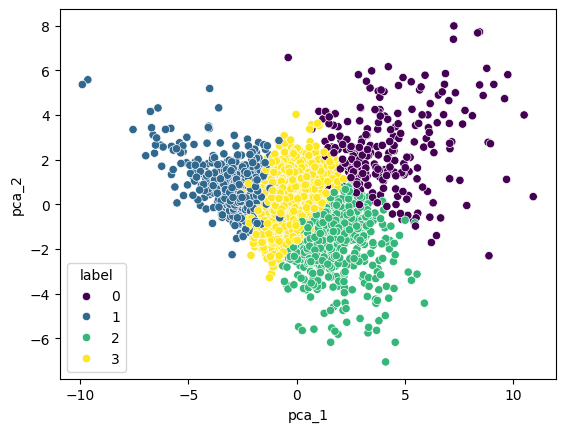

In [16]:
from sklearn.cluster import HDBSCAN
from sklearn.cluster import KMeans

#TODO: go from pca to pca_rotated

#clusterer = HDBSCAN(min_cluster_size=5, copy=False)
clusterer = KMeans(n_clusters=4, random_state=42)
clusterer.fit(df_pca)

# Результаты
labels = clusterer.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)  # -1 метка для шума
n_noise = list(labels).count(-1)

print(f"Количество найденных кластеров: {n_clusters}")
print(f"Количество точек, отнесённых к шуму: {n_noise}")
print(f"Метки кластеров (первые 10): {labels[:10]}")
print("\nЧисло наблюдений в каждом кластере:")
#print(clusterer.probabilities_[:10])
for i in set(labels):
    print(i, np.sum(labels == i))

df_final['label'] = labels
#plt.scatter(df_pca['pca_1'], df_pca['pca_2'], с=labels, cmap='viridis')
sns.scatterplot(df_pca, x='pca_1', y='pca_2', hue=df_final['label'], palette='viridis')
plt.show()

In [17]:
for i in range(4):
    print(df_final[df_final['label'] == i]['int_score'].mean())

1.500656794336787
-0.5819870536957039
0.25617415361509677
-0.14720858694439146


In [84]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.model_selection import GridSearchCV

In [85]:
X_train, X_test, y_train, y_test = train_test_split(df_final[NUM_COLS], df_final['label'], train_size=0.7)

rf = RandomForestClassifier(random_state=42)
scores = cross_val_score(rf, X_train, y_train, cv=5)

In [86]:
scores

array([0.91005291, 0.90981432, 0.91777188, 0.88594164, 0.88328912])

Hyperparameter tuning

In [ ]:
hyperparams = {
    'n_estimators': [100, 125, 150],
    'max_depth': [24, 30, 36, None],
    'min_samples_leaf': [1, 2, 3]
}

cross_val = GridSearchCV(rf, hyperparams, cv=5)
cross_val.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [18, 24, ...], 'min_samples_leaf': [1, 2], 'n_estimators': [100, 125, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : t

In [88]:
print(f"Optimal hyperparameter: {cross_val.best_params_}")
means = cross_val.cv_results_['mean_test_score']
stds = cross_val.cv_results_['std_test_score']

for mean, std, params in zip(means, stds, cross_val.cv_results_['params']):
    if mean > 0.9015:
        print(f"Mean {round(mean,3)} Standard Deviation {round(std * 2, 3)} Hyperparameters {params}")

Optimal hyperparameter: {'max_depth': 30, 'min_samples_leaf': 1, 'n_estimators': 125}
Mean 0.903 Standard Deviation 0.021 Hyperparameters {'max_depth': 30, 'min_samples_leaf': 1, 'n_estimators': 125}
Mean 0.903 Standard Deviation 0.021 Hyperparameters {'max_depth': 36, 'min_samples_leaf': 1, 'n_estimators': 125}
Mean 0.903 Standard Deviation 0.021 Hyperparameters {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 125}


In [89]:
rfs = [
    RandomForestClassifier(n_estimators=175, max_depth=36, min_samples_leaf=2, class_weight=None)
]

for mdl in rfs:
    mdl.fit(X_train, y_train)

In [90]:
for mdl in rfs:
    y_pred = mdl.predict(X_test)
    accuracy = round(accuracy_score(y_test, y_pred), 3)
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    print('Max Depth: {} || Estimators: {} || Accuracy: {} || Precision: {} || Recall: {}'.format(mdl.max_depth,
                                                                                                mdl.n_estimators,
                                                                                                accuracy,
                                                                                                precision,
                                                                                                recall))

Max Depth: 36 || Estimators: 175 || Accuracy: 0.905 || Precision: 0.919784142986671 || Recall: 0.8736866657290885


In [91]:
confusion_matrix(y_test, y_pred)

array([[ 53,   0,   6,   5],
       [  0, 131,   0,  19],
       [  1,   0, 142,  26],
       [  2,   7,  11, 406]])